In [1]:
import os
import re
from pathlib import Path
from collections import Counter, defaultdict
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from IPython.display import display

print("Libraries imported successfully.")


# ============================================================
# PATHS
# ============================================================

DATA_ROOT = Path(r"D:\nti_project\data")

DETECTION_ROOT = DATA_ROOT / "Damage Detection"

SEGMENTATION_ROOT = DATA_ROOT / "Damage Segmentaion"

OUTPUT_ROOT = DATA_ROOT.parent / "audit_results" / "annotation_analysis"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print("DATA_ROOT:", DATA_ROOT)
print("Detection:", DETECTION_ROOT)
print("Segmentation:", SEGMENTATION_ROOT)
print("Output:", OUTPUT_ROOT)

print("\nExists:")
print("DATA_ROOT:", DATA_ROOT.exists())
print("Detection:", DETECTION_ROOT.exists())
print("Segmentation:", SEGMENTATION_ROOT.exists())

Libraries imported successfully.
DATA_ROOT: D:\nti_project\data
Detection: D:\nti_project\data\Damage Detection
Segmentation: D:\nti_project\data\Damage Segmentaion
Output: D:\nti_project\audit_results\annotation_analysis

Exists:
DATA_ROOT: True
Detection: True
Segmentation: True


In [2]:
def get_image_files(folder):
    """Return all image files inside a folder."""
    
    if not folder.exists():
        return []
    
    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


def get_files_recursive(folder, extensions=None):
    """Recursively return files matching extensions."""
    
    if not folder.exists():
        return []
    
    files = []
    
    for p in folder.rglob("*"):
        if p.is_file():
            if extensions is None or p.suffix.lower() in extensions:
                files.append(p)
    
    return sorted(files)


def normalize_stem(path):
    """
    Get normalized filename stem.
    Example:
        image_001.jpg -> image_001
    """
    
    return path.stem.lower().strip()


def show_image(image_path, figsize=(6, 6)):
    """Display one image."""
    
    try:
        with Image.open(image_path) as img:
            plt.figure(figsize=figsize)
            plt.imshow(img)
            plt.axis("off")
            plt.title(image_path.name)
            plt.show()
            
    except Exception as e:
        print(f"Could not open {image_path}: {e}")


def safe_open_image(path):
    try:
        return Image.open(path).convert("RGB")
    except Exception:
        return None


print("Helper functions ready.")

Helper functions ready.


In [3]:
detection_images_dir = DETECTION_ROOT / "Images"
detection_labels_dir = DETECTION_ROOT / "Labels"

yolo_dir = detection_labels_dir / "Yolo"
voc_dir = detection_labels_dir / "Pascal VOC"

detection_images = get_image_files(detection_images_dir)
yolo_files = get_files_recursive(yolo_dir, {".txt"})
voc_files = get_files_recursive(voc_dir, {".xml"})

print("========== DETECTION DATASET ==========")

print("Detection images:", len(detection_images))
print("YOLO annotation files:", len(yolo_files))
print("Pascal VOC files:", len(voc_files))

print("\nPaths:")
print("Images:", detection_images_dir)
print("YOLO:", yolo_dir)
print("VOC:", voc_dir)

========== DETECTION DATASET ==========
Detection images: 1500
YOLO annotation files: 1500
Pascal VOC files: 0

Paths:
Images: D:\nti_project\data\Damage Detection\Images
YOLO: D:\nti_project\data\Damage Detection\Labels\Yolo
VOC: D:\nti_project\data\Damage Detection\Labels\Pascal VOC


In [4]:
image_map = {
    normalize_stem(p): p
    for p in detection_images
}

yolo_map = {
    normalize_stem(p): p
    for p in yolo_files
}

image_names = set(image_map.keys())
yolo_names = set(yolo_map.keys())

matched_yolo = image_names & yolo_names
images_without_yolo = image_names - yolo_names
yolo_without_image = yolo_names - image_names

print("========== IMAGE ↔ YOLO ==========")

print("Images:", len(image_names))
print("YOLO labels:", len(yolo_names))

print("Matched:", len(matched_yolo))
print("Images without YOLO:", len(images_without_yolo))
print("YOLO without image:", len(yolo_without_image))

if images_without_yolo:
    print("\nExamples of images without YOLO:")
    for name in sorted(images_without_yolo)[:20]:
        print(name)

if yolo_without_image:
    print("\nExamples of YOLO files without image:")
    for name in sorted(yolo_without_image)[:20]:
        print(name)

========== IMAGE ↔ YOLO ==========
Images: 1500
YOLO labels: 1500
Matched: 1500
Images without YOLO: 0
YOLO without image: 0


In [5]:
def parse_yolo_file(txt_path):
    """
    Parse YOLO annotation file.
    
    Returns list of dictionaries.
    """
    
    annotations = []
    
    try:
        with open(txt_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
            
    except Exception as e:
        print(f"Could not read {txt_path}: {e}")
        return annotations
    
    for line_number, line in enumerate(lines, start=1):
        
        line = line.strip()
        
        if not line:
            continue
        
        parts = line.split()
        
        if len(parts) != 5:
            annotations.append({
                "valid": False,
                "line": line_number,
                "raw": line
            })
            continue
        
        try:
            class_id = int(float(parts[0]))
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
            
            annotations.append({
                "valid": True,
                "line": line_number,
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height
            })
            
        except ValueError:
            annotations.append({
                "valid": False,
                "line": line_number,
                "raw": line
            })
    
    return annotations


yolo_records = []

for txt_file in yolo_files:
    
    annotations = parse_yolo_file(txt_file)
    
    for ann in annotations:
        
        record = {
            "file": txt_file.name,
            "path": str(txt_file),
            **ann
        }
        
        yolo_records.append(record)


yolo_df = pd.DataFrame(yolo_records)

print("YOLO annotation rows:", len(yolo_df))

if not yolo_df.empty:
    display(yolo_df.head())

YOLO annotation rows: 19710


,file,path,valid,line,class_id,x_center,y_center,width,height
0,E (1).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,1,1,0.813281,0.132812,0.367188,0.265625
1,E (1).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,2,0,0.574219,0.854688,0.092188,0.284375
2,E (10).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,1,0,0.207031,0.910937,0.220312,0.175000
3,E (10).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,2,0,0.219531,0.721094,0.032813,0.204687
4,E (10).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,3,0,0.499219,0.564844,0.998437,0.051562


In [6]:
def parse_yolo_file(txt_path):
    """
    Parse YOLO annotation file.
    
    Returns list of dictionaries.
    """
    
    annotations = []
    
    try:
        with open(txt_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
            
    except Exception as e:
        print(f"Could not read {txt_path}: {e}")
        return annotations
    
    for line_number, line in enumerate(lines, start=1):
        
        line = line.strip()
        
        if not line:
            continue
        
        parts = line.split()
        
        if len(parts) != 5:
            annotations.append({
                "valid": False,
                "line": line_number,
                "raw": line
            })
            continue
        
        try:
            class_id = int(float(parts[0]))
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
            
            annotations.append({
                "valid": True,
                "line": line_number,
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height
            })
            
        except ValueError:
            annotations.append({
                "valid": False,
                "line": line_number,
                "raw": line
            })
    
    return annotations


yolo_records = []

for txt_file in yolo_files:
    
    annotations = parse_yolo_file(txt_file)
    
    for ann in annotations:
        
        record = {
            "file": txt_file.name,
            "path": str(txt_file),
            **ann
        }
        
        yolo_records.append(record)


yolo_df = pd.DataFrame(yolo_records)

print("YOLO annotation rows:", len(yolo_df))

if not yolo_df.empty:
    display(yolo_df.head())

YOLO annotation rows: 19710


,file,path,valid,line,class_id,x_center,y_center,width,height
0,E (1).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,1,1,0.813281,0.132812,0.367188,0.265625
1,E (1).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,2,0,0.574219,0.854688,0.092188,0.284375
2,E (10).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,1,0,0.207031,0.910937,0.220312,0.175000
3,E (10).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,2,0,0.219531,0.721094,0.032813,0.204687
4,E (10).txt,D:\nti_project\data\Damage Detection\Labels\Yo...,True,3,0,0.499219,0.564844,0.998437,0.051562


========== YOLO CLASS DISTRIBUTION ==========


,annotation_count
class_id,
0,19229
1,481


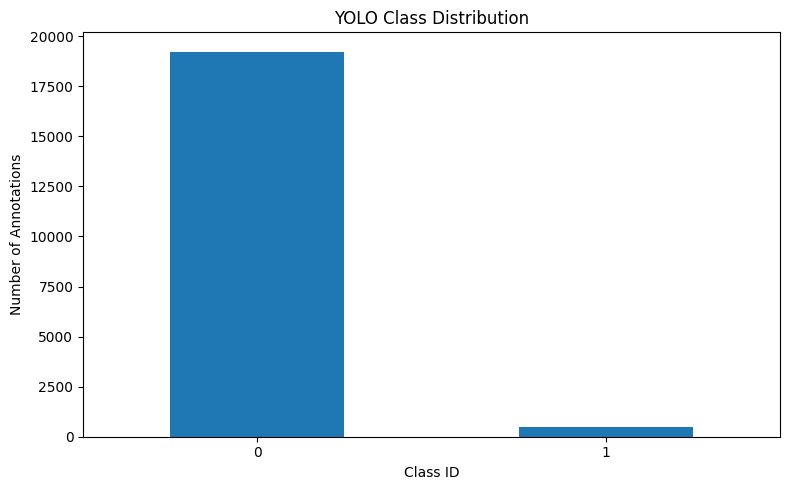

In [7]:
if not yolo_df.empty:
    
    valid_yolo = yolo_df[yolo_df["valid"] == True]
    
    class_counts = (
        valid_yolo["class_id"]
        .value_counts()
        .sort_index()
    )
    
    print("========== YOLO CLASS DISTRIBUTION ==========")
    display(class_counts.to_frame("annotation_count"))
    
    plt.figure(figsize=(8, 5))
    
    class_counts.plot(kind="bar")
    
    plt.xlabel("Class ID")
    plt.ylabel("Number of Annotations")
    plt.title("YOLO Class Distribution")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

========== YOLO CLASS DISTRIBUTION ==========


,annotation_count
class_id,
0,19229
1,481


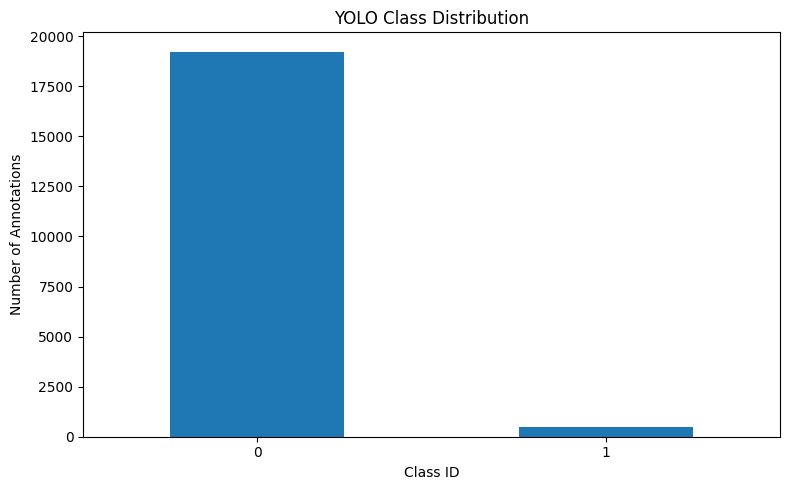

In [8]:
if not yolo_df.empty:
    
    valid_yolo = yolo_df[yolo_df["valid"] == True]
    
    class_counts = (
        valid_yolo["class_id"]
        .value_counts()
        .sort_index()
    )
    
    print("========== YOLO CLASS DISTRIBUTION ==========")
    display(class_counts.to_frame("annotation_count"))
    
    plt.figure(figsize=(8, 5))
    
    class_counts.plot(kind="bar")
    
    plt.xlabel("Class ID")
    plt.ylabel("Number of Annotations")
    plt.title("YOLO Class Distribution")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [9]:
def parse_voc_file(xml_path):
    """
    Parse Pascal VOC XML.
    Returns image information + objects.
    """
    
    records = []
    
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
    except Exception as e:
        return [{
            "valid": False,
            "error": str(e),
            "file": xml_path.name,
            "path": str(xml_path)
        }]
    
    filename_node = root.find("filename")
    
    filename = (
        filename_node.text.strip()
        if filename_node is not None and filename_node.text
        else None
    )
    
    objects = root.findall("object")
    
    if not objects:
        
        records.append({
            "valid": True,
            "file": xml_path.name,
            "path": str(xml_path),
            "filename": filename,
            "class_name": None,
            "xmin": None,
            "ymin": None,
            "xmax": None,
            "ymax": None
        })
        
        return records
    
    for obj in objects:
        
        name_node = obj.find("name")
        bbox = obj.find("bndbox")
        
        class_name = (
            name_node.text.strip()
            if name_node is not None and name_node.text
            else None
        )
        
        if bbox is None:
            records.append({
                "valid": False,
                "file": xml_path.name,
                "path": str(xml_path),
                "filename": filename,
                "class_name": class_name
            })
            continue
        
        def get_value(tag):
            node = bbox.find(tag)
            return float(node.text) if node is not None else None
        
        records.append({
            "valid": True,
            "file": xml_path.name,
            "path": str(xml_path),
            "filename": filename,
            "class_name": class_name,
            "xmin": get_value("xmin"),
            "ymin": get_value("ymin"),
            "xmax": get_value("xmax"),
            "ymax": get_value("ymax")
        })
    
    return records


voc_records = []

for xml_file in voc_files:
    voc_records.extend(parse_voc_file(xml_file))


voc_df = pd.DataFrame(voc_records)

print("========== PASCAL VOC ==========")

print("VOC annotation rows:", len(voc_df))

display(voc_df.head())

========== PASCAL VOC ==========
VOC annotation rows: 0


""


In [10]:
if not voc_df.empty:
    
    valid_voc = voc_df[voc_df["valid"] == True].copy()
    
    invalid_voc = voc_df[voc_df["valid"] == False].copy()
    
    print("========== VOC VALIDATION ==========")
    
    print("Total rows:", len(voc_df))
    print("Valid:", len(valid_voc))
    print("Invalid:", len(invalid_voc))
    
    if "class_name" in valid_voc.columns:
        
        print("\nVOC classes:")
        
        voc_classes = (
            valid_voc["class_name"]
            .dropna()
            .value_counts()
        )
        
        display(voc_classes.to_frame("annotation_count"))

In [11]:
if not yolo_df.empty and not voc_df.empty:
    
    valid_yolo = yolo_df[yolo_df["valid"] == True].copy()
    valid_voc = voc_df[voc_df["valid"] == True].copy()
    
    print("========== YOLO vs VOC ==========")
    
    print("YOLO images with annotations:",
          valid_yolo["file"].nunique())
    
    print("VOC images with annotations:",
          valid_voc["file"].nunique())
    
    print("\nVOC class names:")
    print(
        sorted(
            valid_voc["class_name"]
            .dropna()
            .unique()
        )
    )
    
    print("\nYOLO class IDs:")
    print(
        sorted(
            valid_yolo["class_id"]
            .unique()
        )
    )

In [12]:
if not yolo_df.empty and not voc_df.empty:
    
    valid_yolo = yolo_df[yolo_df["valid"] == True].copy()
    valid_voc = voc_df[voc_df["valid"] == True].copy()
    
    print("========== YOLO vs VOC ==========")
    
    print("YOLO images with annotations:",
          valid_yolo["file"].nunique())
    
    print("VOC images with annotations:",
          valid_voc["file"].nunique())
    
    print("\nVOC class names:")
    print(
        sorted(
            valid_voc["class_name"]
            .dropna()
            .unique()
        )
    )
    
    print("\nYOLO class IDs:")
    print(
        sorted(
            valid_yolo["class_id"]
            .unique()
        )
    )

In [14]:
import pandas as pd
from pathlib import Path

# 1. تعريف مستويات الـ Segmentation
segmentation_levels = ["Easy", "Medium", "Hard"]

# 2. تعريف الدوال المساعدة (في حال عدم تعريفها سابقاً)
def normalize_stem(path):
    return path.stem.lower().strip()

def get_files_recursive(folder_path, extensions):
    folder_path = Path(folder_path)
    if not folder_path.exists():
        return []
    return [p for p in folder_path.rglob("*") if p.is_file() and p.suffix.lower() in extensions]

# 3. تشغيل الكود الرئيسي
segmentation_matching = []

for level in segmentation_levels:
    level_root = SEGMENTATION_ROOT / level
    
    images = get_image_files(level_root / "Images")
    masks = get_image_files(level_root / "Labels" / "Mask")
    yolo = get_files_recursive(
        level_root / "Labels" / "Yolo",
        {".txt"}
    )
    voc = get_files_recursive(
        level_root / "Labels" / "Pascal VOC",
        {".xml"}
    )
    
    image_stems = {
        normalize_stem(p)
        for p in images
    }
    
    mask_stems = {
        normalize_stem(p)
        for p in masks
    }
    
    yolo_stems = {
        normalize_stem(p)
        for p in yolo
    }
    
    voc_stems = {
        normalize_stem(p)
        for p in voc
    }
    
    segmentation_matching.append({
        "level": level,
        "images": len(image_stems),
        "masks": len(mask_stems),
        "image_mask_match": len(image_stems & mask_stems),
        "images_without_mask": len(image_stems - mask_stems),
        "mask_without_image": len(mask_stems - image_stems),
        "image_yolo_match": len(image_stems & yolo_stems),
        "image_voc_match": len(image_stems & voc_stems)
    })

segmentation_matching_df = pd.DataFrame(segmentation_matching)
display(segmentation_matching_df)

,level,images,masks,image_mask_match,images_without_mask,mask_without_image,image_yolo_match,image_voc_match
0,Easy,500,500,0,500,500,500,0
1,Medium,500,500,0,500,500,500,0
2,Hard,500,500,0,500,500,500,0


In [15]:
def analyze_mask(mask_path):
    """
    Analyze unique pixel values in a mask.
    """
    
    try:
        with Image.open(mask_path) as mask:
            
            arr = np.array(mask)
            
            unique_values = np.unique(arr)
            
            return {
                "file": mask_path.name,
                "width": mask.width,
                "height": mask.height,
                "mode": mask.mode,
                "channels": (
                    1 if arr.ndim == 2
                    else arr.shape[-1]
                ),
                "unique_values_count": len(unique_values),
                "unique_values": unique_values[:50].tolist()
            }
            
    except Exception as e:
        
        return {
            "file": mask_path.name,
            "error": str(e)
        }


mask_analysis_records = []

for level in segmentation_levels:
    
    mask_dir = (
        SEGMENTATION_ROOT
        / level
        / "Labels"
        / "Mask"
    )
    
    masks = get_image_files(mask_dir)
    
    print(f"{level}: {len(masks)} masks")
    
    for mask in masks:
        
        result = analyze_mask(mask)
        result["level"] = level
        
        mask_analysis_records.append(result)


mask_df = pd.DataFrame(mask_analysis_records)

print("\n========== MASK ANALYSIS ==========")

display(mask_df.head())

Easy: 500 masks
Medium: 500 masks
Hard: 500 masks

========== MASK ANALYSIS ==========


,file,width,height,mode,channels,unique_values_count,unique_values,level
0,E (1)_mask.png,640,640,RGB,3,2,"[0, 255]",Easy
1,E (10)_mask.png,640,640,RGB,3,2,"[0, 255]",Easy
2,E (100)_mask.png,640,640,RGB,3,2,"[0, 255]",Easy
3,E (101)_mask.png,640,640,RGB,3,2,"[0, 255]",Easy
4,E (102)_mask.png,640,640,RGB,3,2,"[0, 255]",Easy


In [16]:
if not mask_df.empty:
    
    print("========== MASK UNIQUE VALUES ==========")
    
    all_values = Counter()
    
    for values in mask_df["unique_values"].dropna():
        
        for value in values:
            all_values[value] += 1
    
    print("Unique pixel values found across masks:")
    
    for value, count in sorted(all_values.items()):
        print(f"{value}: appears in {count} masks")

========== MASK UNIQUE VALUES ==========
Unique pixel values found across masks:
0: appears in 1500 masks
255: appears in 1497 masks


In [17]:
dimension_records = []

for level in segmentation_levels:
    
    images_dir = SEGMENTATION_ROOT / level / "Images"
    mask_dir = SEGMENTATION_ROOT / level / "Labels" / "Mask"
    
    images = {
        normalize_stem(p): p
        for p in get_image_files(images_dir)
    }
    
    masks = {
        normalize_stem(p): p
        for p in get_image_files(mask_dir)
    }
    
    matched = set(images.keys()) & set(masks.keys())
    
    for stem in matched:
        
        image_path = images[stem]
        mask_path = masks[stem]
        
        try:
            with Image.open(image_path) as img:
                image_size = (img.width, img.height)
            
            with Image.open(mask_path) as mask:
                mask_size = (mask.width, mask.height)
            
            dimension_records.append({
                "level": level,
                "stem": stem,
                "image_width": image_size[0],
                "image_height": image_size[1],
                "mask_width": mask_size[0],
                "mask_height": mask_size[1],
                "same_size": image_size == mask_size
            })
            
        except Exception as e:
            
            dimension_records.append({
                "level": level,
                "stem": stem,
                "same_size": False,
                "error": str(e)
            })


dimension_df = pd.DataFrame(dimension_records)

print("========== IMAGE ↔ MASK DIMENSIONS ==========")

if not dimension_df.empty:
    
    print(
        "Matched image/mask pairs:",
        len(dimension_df)
    )
    
    print(
        "Same dimensions:",
        dimension_df["same_size"].sum()
    )
    
    print(
        "Different dimensions:",
        (~dimension_df["same_size"]).sum()
    )
    
    display(
        dimension_df[
            dimension_df["same_size"] == False
        ].head(20)
    )

========== IMAGE ↔ MASK DIMENSIONS ==========


In [18]:
dimension_records = []

for level in segmentation_levels:
    
    images_dir = SEGMENTATION_ROOT / level / "Images"
    mask_dir = SEGMENTATION_ROOT / level / "Labels" / "Mask"
    
    images = {
        normalize_stem(p): p
        for p in get_image_files(images_dir)
    }
    
    masks = {
        normalize_stem(p): p
        for p in get_image_files(mask_dir)
    }
    
    matched = set(images.keys()) & set(masks.keys())
    
    for stem in matched:
        
        image_path = images[stem]
        mask_path = masks[stem]
        
        try:
            with Image.open(image_path) as img:
                image_size = (img.width, img.height)
            
            with Image.open(mask_path) as mask:
                mask_size = (mask.width, mask.height)
            
            dimension_records.append({
                "level": level,
                "stem": stem,
                "image_width": image_size[0],
                "image_height": image_size[1],
                "mask_width": mask_size[0],
                "mask_height": mask_size[1],
                "same_size": image_size == mask_size
            })
            
        except Exception as e:
            
            dimension_records.append({
                "level": level,
                "stem": stem,
                "same_size": False,
                "error": str(e)
            })


dimension_df = pd.DataFrame(dimension_records)

print("========== IMAGE ↔ MASK DIMENSIONS ==========")

if not dimension_df.empty:
    
    print(
        "Matched image/mask pairs:",
        len(dimension_df)
    )
    
    print(
        "Same dimensions:",
        dimension_df["same_size"].sum()
    )
    
    print(
        "Different dimensions:",
        (~dimension_df["same_size"]).sum()
    )
    
    display(
        dimension_df[
            dimension_df["same_size"] == False
        ].head(20)
    )

========== IMAGE ↔ MASK DIMENSIONS ==========


Image: D:\nti_project\data\Damage Detection\Images\E (1).jpg
YOLO: D:\nti_project\data\Damage Detection\Labels\Yolo\E (1).txt


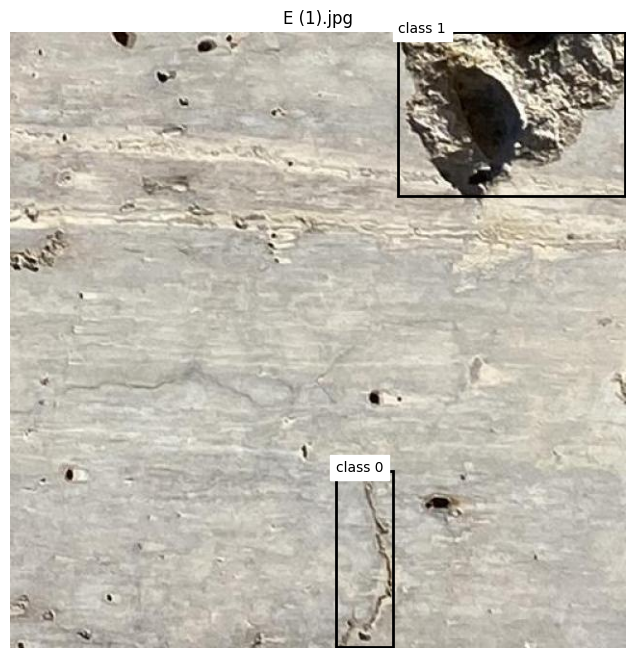

In [19]:
def draw_yolo_boxes(image_path, yolo_path):
    
    img = Image.open(image_path).convert("RGB")
    
    width, height = img.size
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    
    annotations = parse_yolo_file(yolo_path)
    
    for ann in annotations:
        
        if not ann.get("valid", False):
            continue
        
        x_center = ann["x_center"] * width
        y_center = ann["y_center"] * height
        
        box_width = ann["width"] * width
        box_height = ann["height"] * height
        
        xmin = x_center - box_width / 2
        ymin = y_center - box_height / 2
        
        xmax = x_center + box_width / 2
        ymax = y_center + box_height / 2
        
        rect = plt.Rectangle(
            (xmin, ymin),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )
        
        plt.gca().add_patch(rect)
        
        plt.text(
            xmin,
            ymin,
            f"class {ann['class_id']}",
            fontsize=10,
            backgroundcolor="white"
        )
    
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()


# Find first matched sample

if matched_yolo:
    
    sample_stem = sorted(matched_yolo)[0]
    
    sample_image = image_map[sample_stem]
    sample_yolo = yolo_map[sample_stem]
    
    print("Image:", sample_image)
    print("YOLO:", sample_yolo)
    
    draw_yolo_boxes(
        sample_image,
        sample_yolo
    )

Image: D:\nti_project\data\Damage Detection\Images\E (1).jpg
YOLO: D:\nti_project\data\Damage Detection\Labels\Yolo\E (1).txt


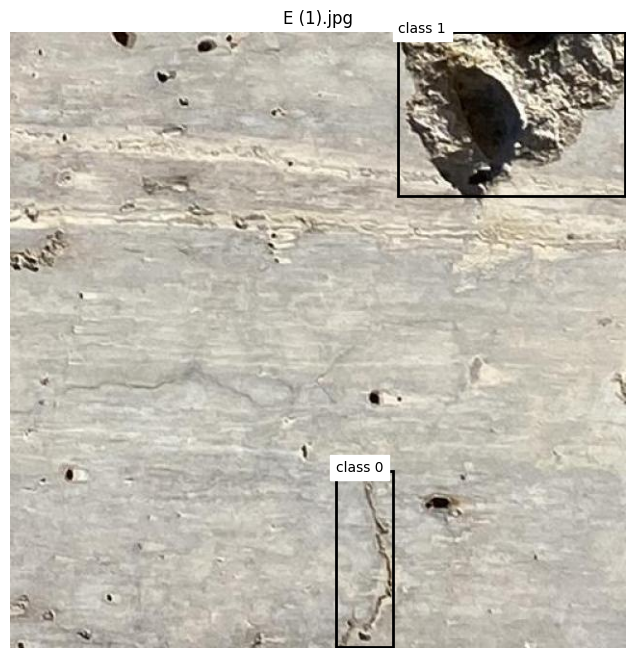

In [20]:
def draw_yolo_boxes(image_path, yolo_path):
    
    img = Image.open(image_path).convert("RGB")
    
    width, height = img.size
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    
    annotations = parse_yolo_file(yolo_path)
    
    for ann in annotations:
        
        if not ann.get("valid", False):
            continue
        
        x_center = ann["x_center"] * width
        y_center = ann["y_center"] * height
        
        box_width = ann["width"] * width
        box_height = ann["height"] * height
        
        xmin = x_center - box_width / 2
        ymin = y_center - box_height / 2
        
        xmax = x_center + box_width / 2
        ymax = y_center + box_height / 2
        
        rect = plt.Rectangle(
            (xmin, ymin),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )
        
        plt.gca().add_patch(rect)
        
        plt.text(
            xmin,
            ymin,
            f"class {ann['class_id']}",
            fontsize=10,
            backgroundcolor="white"
        )
    
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()


# Find first matched sample

if matched_yolo:
    
    sample_stem = sorted(matched_yolo)[0]
    
    sample_image = image_map[sample_stem]
    sample_yolo = yolo_map[sample_stem]
    
    print("Image:", sample_image)
    print("YOLO:", sample_yolo)
    
    draw_yolo_boxes(
        sample_image,
        sample_yolo
    )

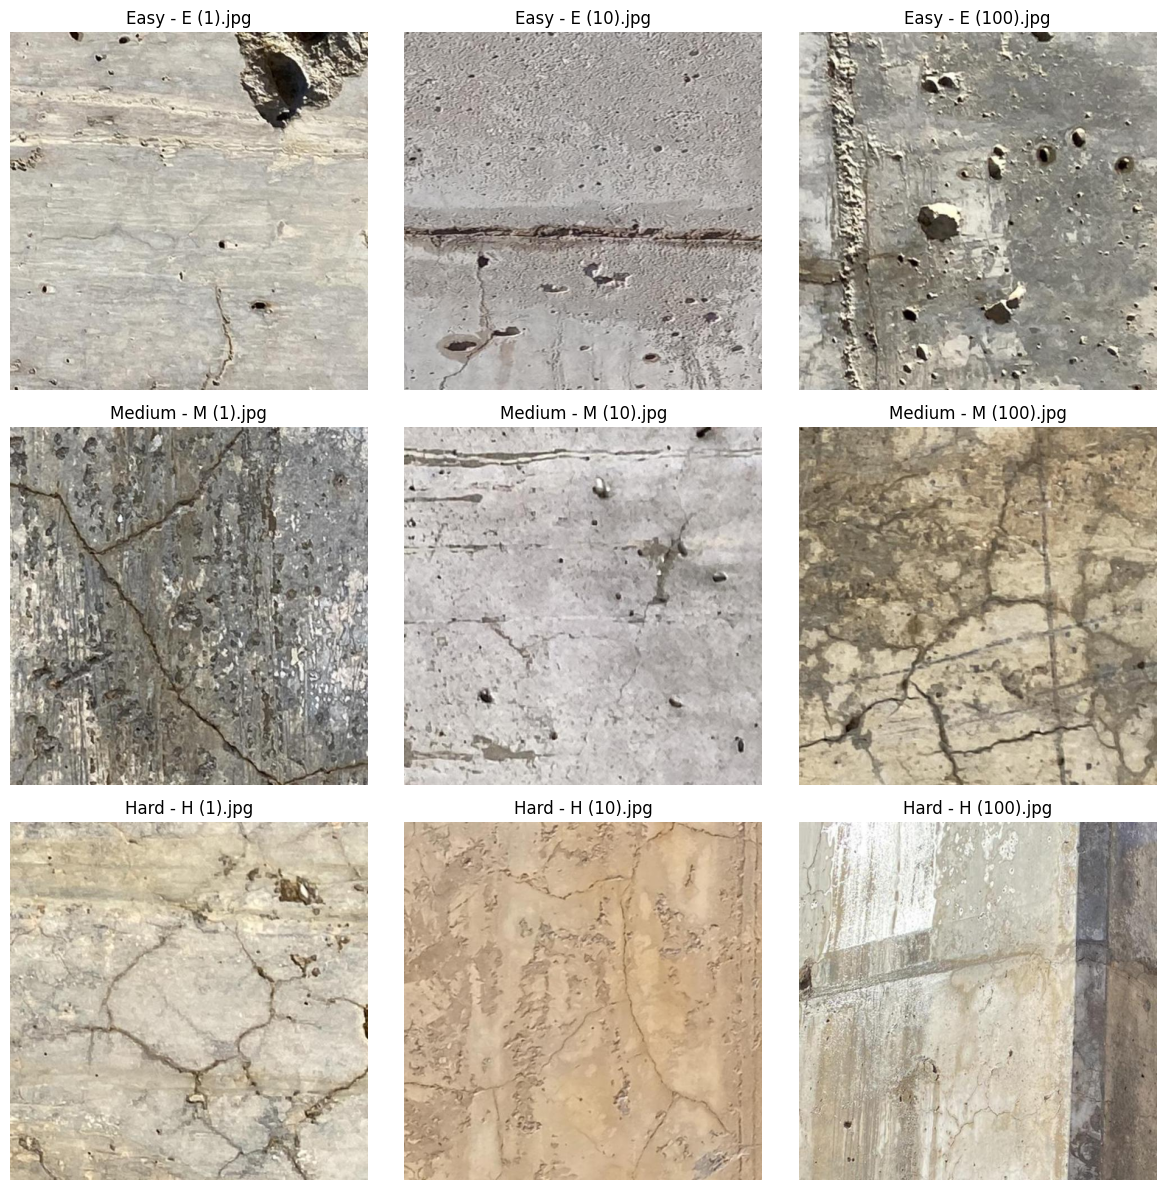

In [21]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)

for row, level in enumerate(segmentation_levels):
    
    images = get_image_files(
        SEGMENTATION_ROOT
        / level
        / "Images"
    )
    
    sample_images = images[:3]
    
    for col in range(3):
        
        if col < len(sample_images):
            
            img = safe_open_image(
                sample_images[col]
            )
            
            if img is not None:
                axes[row, col].imshow(img)
                axes[row, col].axis("off")
                axes[row, col].set_title(
                    f"{level} - {sample_images[col].name}"
                )
        
        else:
            axes[row, col].axis("off")


plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
from pathlib import Path

# 1. التأكد من تعريف المتغيرات والدوال الأساسية
segmentation_levels = ["Easy", "Medium", "Hard"]

def normalize_stem(path):
    return Path(path).stem.lower().strip()

def get_files_recursive(folder_path, extensions):
    folder_path = Path(folder_path)
    if not folder_path.exists():
        return []
    return [p for p in folder_path.rglob("*") if p.is_file() and p.suffix.lower() in extensions]

# 2. بناء قواميس المطبقة للـ Detection أوتوماتيكياً
DETECTION_ROOT = DATA_ROOT / "Damage Detection"

yolo_map = {
    normalize_stem(p): p
    for p in get_files_recursive(DETECTION_ROOT / "Labels" / "Yolo", {".txt"})
}

voc_names = {
    normalize_stem(p): p
    for p in get_files_recursive(DETECTION_ROOT / "Labels" / "Pascal VOC", {".xml"})
}

annotation_inventory = []

# ============================================================
# DETECTION
# ============================================================

for image_path in detection_images:
    
    stem = normalize_stem(image_path)
    
    annotation_inventory.append({
        "dataset": "Damage Detection",
        "level": None,
        "image": str(image_path),
        "stem": stem,
        "yolo": str(yolo_map[stem]) if stem in yolo_map else None,
        "voc": str(voc_names[stem]) if stem in voc_names else None,
        "mask": None
    })


# ============================================================
# SEGMENTATION
# ============================================================

for level in segmentation_levels:
    
    level_root = SEGMENTATION_ROOT / level
    
    images = get_image_files(
        level_root / "Images"
    )
    
    masks = {
        normalize_stem(p): p
        for p in get_image_files(
            level_root / "Labels" / "Mask"
        )
    }
    
    yolo = {
        normalize_stem(p): p
        for p in get_files_recursive(
            level_root / "Labels" / "Yolo",
            {".txt"}
        )
    }
    
    voc = {
        normalize_stem(p): p
        for p in get_files_recursive(
            level_root / "Labels" / "Pascal VOC",
            {".xml"}
        )
    }
    
    for image_path in images:
        
        stem = normalize_stem(image_path)
        
        annotation_inventory.append({
            "dataset": "Damage Segmentation",
            "level": level,
            "image": str(image_path),
            "stem": stem,
            "yolo": str(yolo[stem]) if stem in yolo else None,
            "voc": str(voc[stem]) if stem in voc else None,
            "mask": str(masks[stem]) if stem in masks else None
        })


annotation_inventory_df = pd.DataFrame(
    annotation_inventory
)

print("========== UNIFIED ANNOTATION INVENTORY ==========")
print("Total image records:", len(annotation_inventory_df))

display(annotation_inventory_df.head(20))

========== UNIFIED ANNOTATION INVENTORY ==========
Total image records: 3000


,dataset,level,image,stem,yolo,voc,mask
0,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (1),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
1,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (10),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
2,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (100),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
3,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (101),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
4,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (102),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
5,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (103),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
6,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (104),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
7,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (105),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
8,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (106),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None
9,Damage Detection,NaN,D:\nti_project\data\Damage Detection\Images\E ...,e (107),D:\nti_project\data\Damage Detection\Labels\Yo...,None,None


In [25]:
coverage = {
    "Images": len(annotation_inventory_df),
    "With YOLO": annotation_inventory_df["yolo"].notna().sum(),
    "With VOC": annotation_inventory_df["voc"].notna().sum(),
    "With Mask": annotation_inventory_df["mask"].notna().sum()
}

coverage_df = pd.DataFrame(
    coverage.items(),
    columns=["Annotation", "Count"]
)

display(coverage_df)

,Annotation,Count
0,Images,3000
1,With YOLO,3000
2,With VOC,0
3,With Mask,0


In [27]:
from pathlib import Path
import pandas as pd

print("========== SAVING RESULTS ==========")

# 1. التأكد من المسار المطلوب للحفظ
if 'OUTPUT_ROOT' not in globals():
    if 'OUTPUT_DIR' in globals():
        OUTPUT_ROOT = OUTPUT_DIR
    elif 'DATA_ROOT' in globals():
        OUTPUT_ROOT = DATA_ROOT.parent / "audit_results"
    else:
        OUTPUT_ROOT = Path(r"D:\nti_project\audit_results")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# 2. خريطة بالملفات والـ DataFrames المرتبطة بها
files_to_save = {
    "yolo_annotations.csv": "yolo_df",
    "voc_annotations.csv": "voc_df",
    "segmentation_summary.csv": "segmentation_df",
    "segmentation_matching.csv": "segmentation_matching_df",
    "mask_analysis.csv": "mask_df",
    "image_mask_dimensions.csv": "dimension_df",
    "unified_annotation_inventory.csv": "annotation_inventory_df",
    "annotation_coverage.csv": "coverage_df"
}

# 3. فحص وجود كل DataFrame وحفظه دون توقف
for filename, var_name in files_to_save.items():
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        file_path = OUTPUT_ROOT / filename
        globals()[var_name].to_csv(file_path, index=False)
        print(f"Saved: {filename}")
    else:
        print(f"Skipped (variable '{var_name}' not in memory): {filename}")

print("\nAll available analysis results saved to:")
print(OUTPUT_ROOT)

========== SAVING RESULTS ==========
Saved: yolo_annotations.csv
Saved: voc_annotations.csv
Skipped (variable 'segmentation_df' not in memory): segmentation_summary.csv
Saved: segmentation_matching.csv
Saved: mask_analysis.csv
Saved: image_mask_dimensions.csv
Saved: unified_annotation_inventory.csv
Saved: annotation_coverage.csv

All available analysis results saved to:
D:\nti_project\audit_results\annotation_analysis


In [29]:
import pandas as pd
from IPython.display import display

# دالة مساعدة لجلب المتغير بأمان من الذاكرة
def safe_get(var_name, default=None):
    return globals().get(var_name, default)

print("=" * 70)
print("ANNOTATION ANALYSIS FINAL REPORT")
print("=" * 70)

# [DETECTION]
detection_imgs = safe_get("detection_images", [])
yolo_fls = safe_get("yolo_files", [])
voc_fls = safe_get("voc_files", [])

print("\n[DETECTION]")
print("Images:", len(detection_imgs))
print("YOLO files:", len(yolo_fls))
print("VOC files:", len(voc_fls))

# [YOLO]
yolo_data = safe_get("yolo_df", pd.DataFrame())
print("\n[YOLO]")
if not yolo_data.empty and "valid" in yolo_data.columns:
    print("Annotation rows:", len(yolo_data))
    print("Valid:", (yolo_data["valid"] == True).sum())
    print("Invalid:", (yolo_data["valid"] == False).sum())
else:
    print("YOLO data not available in memory.")

# [PASCAL VOC]
voc_data = safe_get("voc_df", pd.DataFrame())
print("\n[PASCAL VOC]")
if not voc_data.empty and "valid" in voc_data.columns:
    print("Annotation rows:", len(voc_data))
    print("Valid:", (voc_data["valid"] == True).sum())
    print("Invalid:", (voc_data["valid"] == False).sum())
else:
    print("VOC data not available in memory.")

# [SEGMENTATION]
print("\n[SEGMENTATION]")
seg_df = safe_get("segmentation_df")
if seg_df is not None:
    display(seg_df)
else:
    print("segmentation_df is not loaded.")

# [IMAGE ↔ MASK]
print("\n[IMAGE ↔ MASK]")
seg_match_df = safe_get("segmentation_matching_df")
if seg_match_df is not None:
    display(seg_match_df)
else:
    print("segmentation_matching_df is not loaded.")

# [MASK]
mask_data = safe_get("mask_df", pd.DataFrame())
print("\n[MASK]")
if not mask_data.empty:
    print("Total masks analyzed:", len(mask_data))
    if "mode" in mask_data.columns:
        print("Modes:", mask_data["mode"].value_counts().to_dict())
else:
    print("Mask data not available in memory.")

# [COVERAGE]
print("\n[COVERAGE]")
cov_df = safe_get("coverage_df")
if cov_df is not None:
    display(cov_df)
else:
    print("coverage_df is not loaded.")

print("\n" + "=" * 70)
print("Analysis completed.")
print("=" * 70)

ANNOTATION ANALYSIS FINAL REPORT

[DETECTION]
Images: 1500
YOLO files: 1500
VOC files: 0

[YOLO]
Annotation rows: 19710
Valid: 19710
Invalid: 0

[PASCAL VOC]
VOC data not available in memory.

[SEGMENTATION]
segmentation_df is not loaded.

[IMAGE ↔ MASK]


,level,images,masks,image_mask_match,images_without_mask,mask_without_image,image_yolo_match,image_voc_match
0,Easy,500,500,0,500,500,500,0
1,Medium,500,500,0,500,500,500,0
2,Hard,500,500,0,500,500,500,0



[MASK]
Total masks analyzed: 1500
Modes: {'RGB': 1500}

[COVERAGE]


,Annotation,Count
0,Images,3000
1,With YOLO,3000
2,With VOC,0
3,With Mask,0



Analysis completed.


--- All core libraries loaded successfully ---
DATA_ROOT: D:\nti_project\data (Exists: True)
OUTPUT_DIR: D:\nti_project\audit_results\annotation_analysis
--- Helper functions compiled ---
 1. PASCAL VOC DEEP DISCOVERY AUDIT
Total XML files discovered across entire DATA_ROOT: 0


,Path,Exists,Total Items,XML Count
0,Damage Detection\Labels\Pascal VOC,True,1500,0
1,Damage Segmentaion\Easy\Labels\Pascal VOC,True,500,0
2,Damage Segmentaion\Medium\Labels\Pascal VOC,True,500,0
3,Damage Segmentaion\Hard\Labels\Pascal VOC,True,500,0


Parsed VOC Bounding Boxes Total: 0

 2. YOLO ANNOTATIONS & CLASS ID AUDIT
Total YOLO txt files discovered: 3000
Parsed YOLO Bounding Box rows: 39420

YOLO Class ID Distribution:


,Class ID,Count
0,0,38458
1,1,962


Out-of-bound Bounding Boxes count: 25

 3. SEGMENTATION MATCHING AUDIT (WITH FIXED NORMALIZATION)


...


 4. DEEP MASK PIXEL & BINARY VALIDATION AUDIT
Total Masks Analyzed: 1500
Is R==G==B Replicated Grayscale across all masks? False
Are all masks Binary (<= 2 unique pixel values)? True

Blank Masks Count (0 foreground pixels): 3


,mask_path,width,height,unique_values
6,D:\nti_project\data\Damage Segmentaion\Easy\La...,640,640,[np.uint8(0)]
133,D:\nti_project\data\Damage Segmentaion\Easy\La...,640,640,[np.uint8(0)]
139,D:\nti_project\data\Damage Segmentaion\Easy\La...,640,640,[np.uint8(0)]



 5. DATA LEAKAGE & CROSS-TASK OVERLAP AUDIT
Hashing 55,348 images for duplicate inspection...
Unique image hashes: 50,738
Duplicate image hash groups found: 3,031
Cross-Task Leakage Groups (Same image in different task folders): 1500


,hash,count,folders_involved,paths
0,ca597d3e9cca0a834f3e386913dc921b,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (1).jpg, Damage Seg..."
1,bb210609e0d8dcfcc46272f4780e1222,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (10).jpg, Damage Se..."
2,c5f3809f6b078b3a0270b0c54d295ccf,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (100).jpg, Damage S..."
3,09dbfb06fb806753eec5c19ae7f8b750,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (101).jpg, Damage S..."
4,ddf3b29cd72fd648b1acc3638e9cefca,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (102).jpg, Damage S..."
5,5c7e45fad083cb49a38b492bd9deb77b,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (103).jpg, Damage S..."
6,3f4ae46ccde3adf678a885e1125cbeb9,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (104).jpg, Damage S..."
7,a25dcac222fe25eeff9ba6871b1c61bf,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (105).jpg, Damage S..."
8,6526db177ab15191c48851e3386f9779,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (106).jpg, Damage S..."
9,0d2e2ddca02b7dae5d726d05509b524c,2,"[Damage Segmentaion, Damage Detection]","[Damage Detection\Images\E (107).jpg, Damage S..."



 6. VISUAL INSPECTION & OVERLAY CHECKS


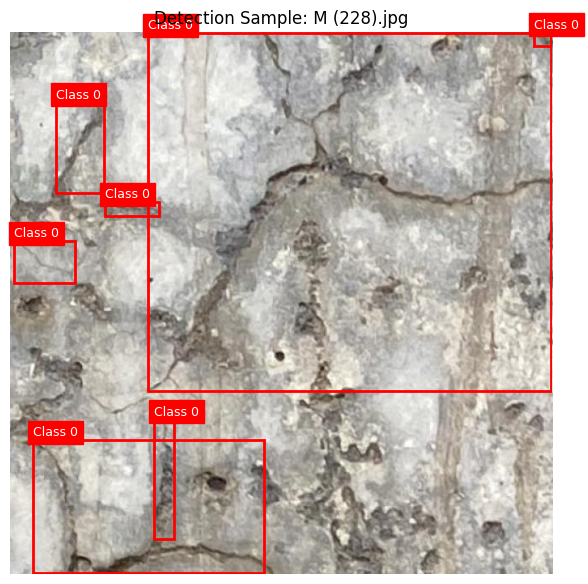

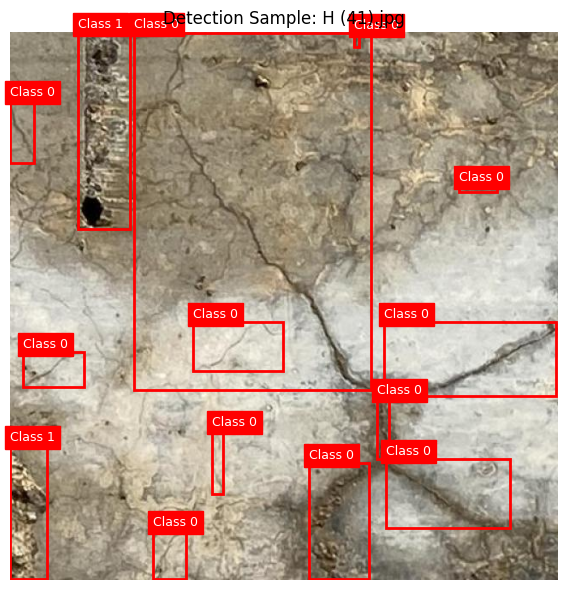


 7. UNIFIED ANNOTATION INVENTORY BUILD
Total Unified Image Inventory Records: 53,848


,relative_path,task_folder,sub_folder,filename,stem,has_yolo,yolo_path,has_voc,voc_path,has_mask,mask_path
0,Background\0001.jpg,Background,Background,0001.jpg,0001,False,NaN,False,None,False,NaN
1,Background\0002.jpg,Background,Background,0002.jpg,0002,False,NaN,False,None,False,NaN
2,Background\0003.jpg,Background,Background,0003.jpg,0003,False,NaN,False,None,False,NaN
3,Background\0004.jpg,Background,Background,0004.jpg,0004,False,NaN,False,None,False,NaN
4,Background\0005.jpg,Background,Background,0005.jpg,0005,False,NaN,False,None,False,NaN
5,Background\0006.jpg,Background,Background,0006.jpg,0006,False,NaN,False,None,False,NaN
6,Background\0007.jpg,Background,Background,0007.jpg,0007,False,NaN,False,None,False,NaN
7,Background\0008.jpg,Background,Background,0008.jpg,0008,False,NaN,False,None,False,NaN
8,Background\0009.jpg,Background,Background,0009.jpg,0009,False,NaN,False,None,False,NaN
9,Background\0010.jpg,Background,Background,0010.jpg,0010,False,NaN,False,None,False,NaN



All audit results successfully saved to: D:\nti_project\audit_results\annotation_analysis

 ANNOTATION ANALYSIS V2 SUMMARY REPORT
1. Total Dataset Images Indexed (Excluding Masks): 53,848
2. Object Detection Images matched with YOLO: 3,000
3. Object Detection Images matched with Pascal VOC: 0
4. Segmentation Images matched with Mask (_mask fixed): 3,000
5. Blank Segmentation Masks Detected (0 FG Pixels): 3
6. Cross-Task Image Leakage Groups Found: 1500


In [30]:
# %% [markdown]
# # 02 — Annotation Analysis (Version 2.0)
# **Concrete Structural Damage Detection & Segmentation Project**
# 
# **Objectives:**
# 1. Complete robust audit of Object Detection annotations (YOLO & Pascal VOC).
# 2. Fix Pascal VOC discovery bug via recursive deep-search.
# 3. Solve Segmentation stem matching bug using `normalize_mask_stem`.
# 4. Analyze YOLO class IDs (0 vs 1) objectively without ground-truth assumptions.
# 5. Inspect Segmentation Masks (RGB vs Binary, foreground coverage, blank masks).
# 6. Audit Data Leakage (Image overlaps & Hash duplicates across tasks).
# 7. Generate unified visual checks and export analysis tables to CSV.

# %% 1. Import Libraries & Set Global Environments
import os
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display

print("--- All core libraries loaded successfully ---")

# %% 2. Define Paths & Output Directory
DATA_ROOT = Path(r"D:\nti_project\data")
OUTPUT_DIR = Path(r"D:\nti_project\audit_results\annotation_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_ROOT: {DATA_ROOT} (Exists: {DATA_ROOT.exists()})")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

# Note: Preserving exact folder spelling "Damage Segmentaion"
SEGMENTATION_ROOT = DATA_ROOT / "Damage Segmentaion"
DETECTION_ROOT = DATA_ROOT / "Damage Detection"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# %% 3. Robust Stem Normalization Helpers
def normalize_stem(path):
    """Normalize general image/file stems by lowering and stripping whitespace."""
    if path is None:
        return ""
    return Path(path).stem.lower().strip()

def normalize_mask_stem(path):
    """Normalize mask file stems by stripping common mask suffixes."""
    if path is None:
        return ""
    stem = Path(path).stem.lower().strip()
    suffixes_to_remove = ["_mask", "-mask", " mask", "_label", "-label", "label"]
    for suffix in suffixes_to_remove:
        if stem.endswith(suffix):
            stem = stem[:-len(suffix)].strip()
            break
    return stem

def get_image_files(folder_path):
    """Recursively collect valid image paths."""
    folder = Path(folder_path)
    if not folder.exists():
        return []
    return [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]

def get_files_recursive(folder_path, extensions):
    """Recursively collect files matching specified extensions (case-insensitive)."""
    folder = Path(folder_path)
    if not folder.exists():
        return []
    ext_set = {e.lower() for e in extensions}
    return [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in ext_set]

print("--- Helper functions compiled ---")

# %% 4. Deep VOC Discovery & XML Debugging
print("==================================================")
print(" 1. PASCAL VOC DEEP DISCOVERY AUDIT")
print("==================================================")

voc_xml_files = get_files_recursive(DATA_ROOT, {".xml"})
print(f"Total XML files discovered across entire DATA_ROOT: {len(voc_xml_files)}")

# Inspect specific VOC directories to trace why V1 reported 0 files
voc_search_paths = [
    DETECTION_ROOT / "Labels" / "Pascal VOC",
    SEGMENTATION_ROOT / "Easy" / "Labels" / "Pascal VOC",
    SEGMENTATION_ROOT / "Medium" / "Labels" / "Pascal VOC",
    SEGMENTATION_ROOT / "Hard" / "Labels" / "Pascal VOC"
]

voc_directory_audit = []
for v_path in voc_search_paths:
    exists = v_path.exists()
    all_children = list(v_path.rglob("*")) if exists else []
    xml_count = len([f for f in all_children if f.is_file() and f.suffix.lower() == ".xml"])
    voc_directory_audit.append({
        "Path": str(v_path.relative_to(DATA_ROOT)) if exists else str(v_path),
        "Exists": exists,
        "Total Items": len(all_children),
        "XML Count": xml_count
    })

voc_audit_df = pd.DataFrame(voc_directory_audit)
display(voc_audit_df)

# %% 5. Parse Pascal VOC Annotations (If present)
def parse_voc_xml(xml_path):
    """Parses Pascal VOC XML file and extracts bounding boxes and class names."""
    records = []
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        filename = root.findtext("filename", "")
        size_elem = root.find("size")
        width = int(size_elem.findtext("width")) if size_elem is not None and size_elem.findtext("width") else None
        height = int(size_elem.findtext("height")) if size_elem is not None and size_elem.findtext("height") else None
        
        for obj in root.findall("object"):
            class_name = obj.findtext("name", "unknown").strip()
            bndbox = obj.find("bndbox")
            if bndbox is not None:
                xmin = float(bndbox.findtext("xmin", 0))
                ymin = float(bndbox.findtext("ymin", 0))
                xmax = float(bndbox.findtext("xmax", 0))
                ymax = float(bndbox.findtext("ymax", 0))
                
                records.append({
                    "xml_path": str(xml_path),
                    "stem": normalize_stem(xml_path),
                    "filename": filename,
                    "img_width": width,
                    "img_height": height,
                    "class_name": class_name,
                    "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax
                })
    except Exception as e:
        records.append({
            "xml_path": str(xml_path),
            "stem": normalize_stem(xml_path),
            "error": str(e)
        })
    return records

voc_records = []
for xml_file in voc_xml_files:
    voc_records.extend(parse_voc_xml(xml_file))

voc_df = pd.DataFrame(voc_records)
print(f"Parsed VOC Bounding Boxes Total: {len(voc_df)}")
if not voc_df.empty and "class_name" in voc_df.columns:
    print("\nVOC Class Distribution:")
    display(voc_df["class_name"].value_counts())

# %% 6. YOLO Annotations Audit & Class ID Analysis
print("\n==================================================")
print(" 2. YOLO ANNOTATIONS & CLASS ID AUDIT")
print("==================================================")

yolo_txt_files = get_files_recursive(DATA_ROOT, {".txt"})
print(f"Total YOLO txt files discovered: {len(yolo_txt_files)}")

def parse_yolo_file(txt_path):
    records = []
    try:
        with open(txt_path, "r") as f:
            lines = f.readlines()
        for line_idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                x_center, y_center = float(parts[1]), float(parts[2])
                w, h = float(parts[3]), float(parts[4])
                
                # Sanity check for normalized coordinates [0, 1]
                valid = (0.0 <= x_center <= 1.0) and (0.0 <= y_center <= 1.0) and (0.0 < w <= 1.0) and (0.0 < h <= 1.0)
                
                records.append({
                    "txt_path": str(txt_path),
                    "stem": normalize_stem(txt_path),
                    "line_idx": line_idx,
                    "class_id": class_id,
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": w,
                    "height": h,
                    "valid_bbox": valid
                })
    except Exception as e:
        pass
    return records

yolo_records = []
for txt_file in yolo_txt_files:
    yolo_records.extend(parse_yolo_file(txt_file))

yolo_df = pd.DataFrame(yolo_records)
print(f"Parsed YOLO Bounding Box rows: {len(yolo_df)}")

if not yolo_df.empty:
    print("\nYOLO Class ID Distribution:")
    class_dist = yolo_df["class_id"].value_counts().reset_index()
    class_dist.columns = ["Class ID", "Count"]
    display(class_dist)
    
    invalid_boxes = yolo_df[yolo_df["valid_bbox"] == False]
    print(f"Out-of-bound Bounding Boxes count: {len(invalid_boxes)}")

# %% 7. Segmentation Image ↔ Mask Normalization Audit
print("\n==================================================")
print(" 3. SEGMENTATION MATCHING AUDIT (WITH FIXED NORMALIZATION)")
print("==================================================")

difficulty_levels = ["Easy", "Medium", "Hard"]
seg_audit_results = []

for level in difficulty_levels:
    level_path = SEGMENTATION_ROOT / level
    img_dir = level_path / "Images"
    mask_dir = level_path / "Labels" / "Mask"
    
    images = get_image_files(img_dir)
    masks = get_image_files(mask_dir)
    
    # Generate stem sets using both general and mask-specific normalizations
    img_stems = {normalize_stem(p): p for p in images}
    mask_stems_raw = {normalize_stem(p): p for p in masks}
    mask_stems_clean = {normalize_mask_stem(p): p for p in masks}
    
    raw_matches = set(img_stems.keys()) & set(mask_stems_raw.keys())
    clean_matches = set(img_stems.keys()) & set(mask_stems_clean.keys())
    
    missing_masks = set(img_stems.keys()) - set(mask_stems_clean.keys())
    extra_masks = set(mask_stems_clean.keys()) - set(img_stems.keys())
    
    seg_audit_results.append({
        "Difficulty": level,
        "Total Images": len(images),
        "Total Masks": len(masks),
        "V1 Raw Matches": len(raw_matches),
        "V2 Fixed Matches": len(clean_matches),
        "Images w/o Mask": len(missing_masks),
        "Masks w/o Image": len(extra_masks)
    })

seg_matching_df = pd.DataFrame(seg_audit_results)
display(seg_matching_df)

# %% 8. Deep Mask Pixel Analysis & Blank Mask Detection
print("\n==================================================")
print(" 4. DEEP MASK PIXEL & BINARY VALIDATION AUDIT")
print("==================================================")

all_mask_paths = get_image_files(SEGMENTATION_ROOT)
mask_analysis_records = []

for mask_path in all_mask_paths:
    if "mask" not in mask_path.parent.name.lower():
        continue # Process mask files only
    try:
        with Image.open(mask_path) as img:
            mode = img.mode
            width, height = img.size
            channels = len(img.getbands())
            arr = np.array(img)
            
            # Channel equality check (Are R == G == B?)
            if arr.ndim == 3 and arr.shape[2] >= 3:
                r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
                is_grayscale_replicated = np.array_equal(r, g) and np.array_equal(g, b)
            else:
                is_grayscale_replicated = True # Already single channel
                
            unique_vals = np.unique(arr)
            foreground_pixels = np.count_nonzero(arr > 0)
            total_pixels = arr.size
            fg_percentage = (foreground_pixels / total_pixels) * 100
            
            mask_analysis_records.append({
                "mask_path": str(mask_path),
                "stem_clean": normalize_mask_stem(mask_path),
                "width": width,
                "height": height,
                "mode": mode,
                "channels": channels,
                "is_rgb_replicated": is_grayscale_replicated,
                "unique_values": str(list(unique_vals)),
                "is_binary": len(unique_vals) <= 2,
                "fg_pixels": foreground_pixels,
                "fg_percentage": fg_percentage,
                "is_blank": foreground_pixels == 0
            })
    except Exception as e:
        mask_analysis_records.append({
            "mask_path": str(mask_path),
            "error": str(e)
        })

mask_df = pd.DataFrame(mask_analysis_records)

print(f"Total Masks Analyzed: {len(mask_df)}")
if not mask_df.empty:
    print(f"Is R==G==B Replicated Grayscale across all masks? {mask_df['is_rgb_replicated'].all()}")
    print(f"Are all masks Binary (<= 2 unique pixel values)? {mask_df['is_binary'].all()}")
    
    blank_masks = mask_df[mask_df["is_blank"] == True]
    print(f"\nBlank Masks Count (0 foreground pixels): {len(blank_masks)}")
    if len(blank_masks) > 0:
        display(blank_masks[["mask_path", "width", "height", "unique_values"]])

# %% 9. Data Leakage & Cross-Task Overlap Audit
print("\n==================================================")
print(" 5. DATA LEAKAGE & CROSS-TASK OVERLAP AUDIT")
print("==================================================")

def compute_md5(file_path):
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

all_project_images = get_image_files(DATA_ROOT)
print(f"Hashing {len(all_project_images):,} images for duplicate inspection...")

hash_map = defaultdict(list)
for img_path in all_project_images:
    # Skip masks from leakage hash check
    if "mask" in img_path.parent.name.lower():
        continue
    h = compute_md5(img_path)
    # Store relative path to trace category
    rel_path = img_path.relative_to(DATA_ROOT)
    hash_map[h].append(rel_path)

duplicate_hashes = {h: paths for h, paths in hash_map.items() if len(paths) > 1}
print(f"Unique image hashes: {len(hash_map):,}")
print(f"Duplicate image hash groups found: {len(duplicate_hashes):,}")

# Check cross-folder leakage (e.g., Classification vs Detection vs Segmentation)
cross_task_leakage = []
for h, paths in duplicate_hashes.items():
    top_folders = {p.parts[0] for p in paths}
    if len(top_folders) > 1:
        cross_task_leakage.append({
            "hash": h,
            "count": len(paths),
            "folders_involved": list(top_folders),
            "paths": [str(p) for p in paths]
        })

leakage_df = pd.DataFrame(cross_task_leakage)
print(f"Cross-Task Leakage Groups (Same image in different task folders): {len(leakage_df)}")
if not leakage_df.empty:
    display(leakage_df.head(10))

# %% 10. Visualization Helper: Overlay YOLO BBoxes & Masks
print("\n==================================================")
print(" 6. VISUAL INSPECTION & OVERLAY CHECKS")
print("==================================================")

def visualize_sample_checks(n_samples=3):
    """Draws sample images with YOLO bounding boxes and segmentation masks side-by-side."""
    detection_imgs = get_image_files(DETECTION_ROOT / "Images")
    if not detection_imgs:
        print("No detection images found to visualize.")
        return
        
    sampled_paths = random.sample(detection_imgs, min(n_samples, len(detection_imgs)))
    
    for img_p in sampled_paths:
        stem = normalize_stem(img_p)
        txt_p = DETECTION_ROOT / "Labels" / "Yolo" / f"{img_p.stem}.txt"
        
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        img = Image.open(img_p)
        w, h = img.size
        ax.imshow(img)
        
        if txt_p.exists():
            boxes = parse_yolo_file(txt_p)
            for box in boxes:
                # Convert normalized YOLO (x_center, y_center, width, height) to pixels
                bw = box["width"] * w
                bh = box["height"] * h
                bx = (box["x_center"] * w) - (bw / 2)
                by = (box["y_center"] * h) - (bh / 2)
                
                rect = patches.Rectangle((bx, by), bw, bh, linewidth=2, edgecolor='r', facecolor='none')
                ax.add_patch(rect)
                ax.text(bx, by - 5, f"Class {box['class_id']}", color='white', backgroundcolor='red', fontsize=9)
                
        ax.set_title(f"Detection Sample: {img_p.name}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

visualize_sample_checks(n_samples=2)

# %% 11. Unified Annotation Inventory Build & Export
print("\n==================================================")
print(" 7. UNIFIED ANNOTATION INVENTORY BUILD")
print("==================================================")

inventory_records = []

# Collect all image-annotation matches
all_dataset_images = get_image_files(DATA_ROOT)

yolo_lookup = {normalize_stem(p): p for p in yolo_txt_files}
voc_lookup = {normalize_stem(p): p for p in voc_xml_files}

# Segmentation mask map using cleaned stems
mask_lookup = {}
for m_path in all_mask_paths:
    if "mask" in m_path.parent.name.lower():
        mask_lookup[normalize_mask_stem(m_path)] = m_path

for img_path in all_dataset_images:
    if "mask" in img_path.parent.name.lower():
        continue # Skip masks from image inventory
        
    stem_gen = normalize_stem(img_path)
    stem_mask = normalize_mask_stem(img_path)
    rel_path = img_path.relative_to(DATA_ROOT)
    
    inventory_records.append({
        "relative_path": str(rel_path),
        "task_folder": rel_path.parts[0],
        "sub_folder": str(rel_path.parent),
        "filename": img_path.name,
        "stem": stem_gen,
        "has_yolo": stem_gen in yolo_lookup,
        "yolo_path": str(yolo_lookup[stem_gen].relative_to(DATA_ROOT)) if stem_gen in yolo_lookup else None,
        "has_voc": stem_gen in voc_lookup,
        "voc_path": str(voc_lookup[stem_gen].relative_to(DATA_ROOT)) if stem_gen in voc_lookup else None,
        "has_mask": stem_mask in mask_lookup,
        "mask_path": str(mask_lookup[stem_mask].relative_to(DATA_ROOT)) if stem_mask in mask_lookup else None
    })

inventory_df = pd.DataFrame(inventory_records)
print(f"Total Unified Image Inventory Records: {len(inventory_df):,}")
display(inventory_df.head(15))

# Export all outputs securely
inventory_df.to_csv(OUTPUT_DIR / "unified_annotation_inventory.csv", index=False)
seg_matching_df.to_csv(OUTPUT_DIR / "segmentation_matching_summary.csv", index=False)
if not yolo_df.empty:
    yolo_df.to_csv(OUTPUT_DIR / "yolo_annotations_parsed.csv", index=False)
if not voc_df.empty:
    voc_df.to_csv(OUTPUT_DIR / "voc_annotations_parsed.csv", index=False)
if not mask_df.empty:
    mask_df.to_csv(OUTPUT_DIR / "mask_analysis_summary.csv", index=False)

print(f"\nAll audit results successfully saved to: {OUTPUT_DIR}")

# %% 12. Final Comprehensive Audit Summary
print("\n" + "=" * 70)
print(" ANNOTATION ANALYSIS V2 SUMMARY REPORT")
print("=" * 70)
print(f"1. Total Dataset Images Indexed (Excluding Masks): {len(inventory_df):,}")
print(f"2. Object Detection Images matched with YOLO: {inventory_df['has_yolo'].sum():,}")
print(f"3. Object Detection Images matched with Pascal VOC: {inventory_df['has_voc'].sum():,}")
print(f"4. Segmentation Images matched with Mask (_mask fixed): {inventory_df['has_mask'].sum():,}")
print(f"5. Blank Segmentation Masks Detected (0 FG Pixels): {len(mask_df[mask_df['is_blank'] == True]) if not mask_df.empty else 0}")
print(f"6. Cross-Task Image Leakage Groups Found: {len(leakage_df)}")
print("=" * 70)

In [31]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display

DATA_ROOT = Path(r"D:\nti_project\data")

# 1. البحث عن كافة ملفات الـ JSON
json_files = list(DATA_ROOT.rglob("*.json"))
print(f"Total JSON annotation files found: {len(json_files)}")

if len(json_files) > 0:
    print("\nSample JSON path:")
    print(json_files[0])

    # 2. قراءة وتحليل أول ملف JSON لمعرفة الهيكل (Structure)
    with open(json_files[0], 'r', encoding='utf-8') as f:
        sample_json = json.load(f)

    print("\n========== SAMPLE JSON STRUCTURE ==========")
    print(json.dumps(sample_json, indent=4)[:1000])  # طباعة أول 1000 حرف

    # 3. استخراج أسماء الـ Classes من كافة ملفات الـ JSON
    all_categories = []

    for j_path in json_files:
        try:
            with open(j_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

                # التعامل مع الأشكال المختلفة للـ JSON (COCO format أو Custom Dict)
                if isinstance(data, dict):
                    if "shapes" in data:  # Labelme format
                        for shape in data["shapes"]:
                            all_categories.append(shape.get("label"))
                    elif "categories" in data:  # COCO format
                        for cat in data["categories"]:
                            all_categories.append(cat.get("name"))
                    elif "objects" in data:
                        for obj in data["objects"]:
                            all_categories.append(obj.get("name"))
                    else:
                        # محاولة استخراج أي label متاح
                        for key, val in data.items():
                            if isinstance(val, list):
                                for item in val:
                                    if isinstance(item, dict) and "label" in item:
                                        all_categories.append(item["label"])

                elif isinstance(data, list):
                    for item in data:
                        if isinstance(item, dict) and "label" in item:
                            all_categories.append(item["label"])
        except Exception:
            pass

    print("\n========== DISCOVERED CLASSES IN JSON ==========")
    class_counts = pd.Series(all_categories).value_counts()
    display(class_counts)
else:
    print("No JSON files found in DATA_ROOT.")

Total JSON annotation files found: 3000

Sample JSON path:
D:\nti_project\data\Damage Detection\Labels\Pascal VOC\E (1).json

========== SAMPLE JSON STRUCTURE ==========
{
    "image": {
        "file_name": "E (1).jpg",
        "width": 640,
        "height": 640
    },
    "annotations": [
        {
            "category_id": 1,
            "bbox": [
                403,
                0,
                235,
                170
            ],
            "area": 39950.0,
            "iscrowd": 0
        },
        {
            "category_id": 0,
            "bbox": [
                338,
                456,
                59,
                182
            ],
            "area": 10738.0,
            "iscrowd": 0
        }
    ]
}

========== DISCOVERED CLASSES IN JSON ==========


Series([], Name: count, dtype: int64)

In [32]:
import json
from pathlib import Path
import pandas as pd
from collections import Counter
from IPython.display import display

DATA_ROOT = Path(r"D:\nti_project\data")
OUTPUT_DIR = Path(r"D:\nti_project\audit_results\annotation_analysis")

json_files = list(DATA_ROOT.rglob("*.json"))
print(f"Total JSON files found: {len(json_files)}")

json_records = []
category_counter = Counter()
text_categories = Counter()

for j_path in json_files:
    try:
        with open(j_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        img_info = data.get("image", {})
        img_filename = img_info.get("file_name", j_path.stem + ".jpg")
        img_w = img_info.get("width", 640)
        img_h = img_info.get("height", 640)
        
        # Check if master categories list exists
        if "categories" in data:
            for cat in data["categories"]:
                text_categories[cat.get("id")] = cat.get("name")
                
        annotations = data.get("annotations", [])
        for ann in annotations:
            cat_id = ann.get("category_id")
            bbox = ann.get("bbox", []) # [xmin, ymin, w, h]
            category_counter[cat_id] += 1
            
            if len(bbox) == 4:
                json_records.append({
                    "json_path": str(j_path.relative_to(DATA_ROOT)),
                    "filename": img_filename,
                    "stem": j_path.stem.lower().strip(),
                    "category_id": cat_id,
                    "xmin": bbox[0],
                    "ymin": bbox[1],
                    "width": bbox[2],
                    "height": bbox[3],
                    "area": ann.get("area", bbox[2] * bbox[3]),
                    "img_width": img_w,
                    "img_height": img_h
                })
    except Exception as e:
        pass

json_df = pd.DataFrame(json_records)

print("\n========== JSON CATEGORY ID DISTRIBUTION ==========")
cat_df = pd.DataFrame(category_counter.items(), columns=["Category ID", "Count"]).sort_values("Category ID")
display(cat_df)

if text_categories:
    print("\n========== TEXT LABELS FOUND ==========")
    print(text_categories)
else:
    print("\nNo embedded text category names found in JSON files. Category IDs are numerical (0 and 1).")

# Save parsed JSON inventory
json_df.to_csv(OUTPUT_DIR / "json_annotations_parsed.csv", index=False)
print(f"\nSaved parsed JSON annotations ({len(json_df):,} rows) to:")
print(OUTPUT_DIR / "json_annotations_parsed.csv")

Total JSON files found: 3000

========== JSON CATEGORY ID DISTRIBUTION ==========


,Category ID,Count
1,0,38458
0,1,962



No embedded text category names found in JSON files. Category IDs are numerical (0 and 1).

Saved parsed JSON annotations (39,420 rows) to:
D:\nti_project\audit_results\annotation_analysis\json_annotations_parsed.csv
